In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [4]:
df = pd.read_csv("Test.csv")
print(df)

                Player (Team)       Span  Matches  Innings  Not Outs   Runs  \
0          SR Tendulkar (IND)  1989-2013      200      329        33  15921   
1            RT Ponting (AUS)  1995-2012      168      287        29  13378   
2          JH Kallis (ICC/SA)  1995-2013      166      280        40  13289   
3          R Dravid (ICC/IND)  1996-2012      164      286        32  13288   
4               AN Cook (ENG)  2006-2018      161      291        16  12472   
..                        ...        ...      ...      ...       ...    ...   
428  Mehidy Hasan Miraz (BAN)  2016-2024       43       79         9   1470   
429          BM Duckett (ENG)  2016-2024       21       39         2   1467   
430         DL Houghton (ZIM)  1992-1997       22       36         2   1464   
431           A Symonds (AUS)  2004-2008       26       41         5   1462   
432               B Lee (AUS)  1999-2008       76       90        18   1451   

    High Score  Average  100s  50s  0s  
0         

In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433 entries, 0 to 432
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Player (Team)  433 non-null    object 
 1   Span           433 non-null    object 
 2   Matches        433 non-null    int64  
 3   Innings        433 non-null    int64  
 4   Not Outs       433 non-null    int64  
 5   Runs           433 non-null    int64  
 6   High Score     433 non-null    object 
 7   Average        433 non-null    float64
 8   100s           433 non-null    int64  
 9   50s            433 non-null    int64  
 10  0s             433 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 37.3+ KB


,Matches,Innings,Not Outs,Runs,Average,100s,50s,0s
count,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000,433.000000
mean,63.958430,107.914550,9.697460,3852.986143,38.154342,8.859122,18.630485,8.136259
std,32.651898,53.604343,7.940661,2506.064554,9.303053,8.196714,12.200759,4.924655
min,20.000000,31.000000,0.000000,1451.000000,12.780000,0.000000,0.000000,0.000000
25%,39.000000,69.000000,4.000000,2061.000000,31.830000,3.000000,10.000000,4.000000
50%,55.000000,92.000000,7.000000,2922.000000,37.980000,6.000000,15.000000,7.000000
75%,81.000000,137.000000,13.000000,4876.000000,44.060000,12.000000,24.000000,11.000000
max,200.000000,329.000000,49.000000,15921.000000,99.940000,51.000000,68.000000,39.000000


In [6]:
df.isnull().sum()

Player (Team)    0
Span             0
Matches          0
Innings          0
Not Outs         0
Runs             0
High Score       0
Average          0
100s             0
50s              0
0s               0
dtype: int64

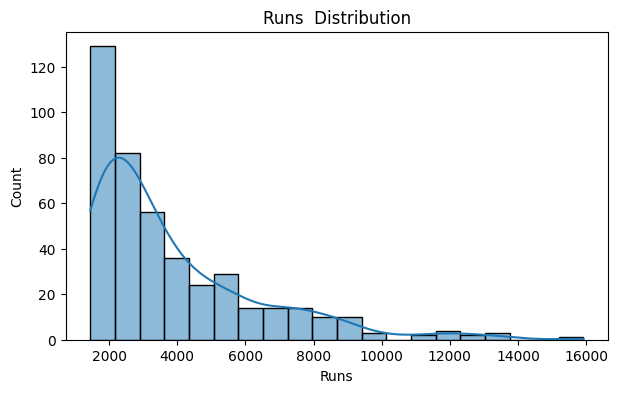

In [10]:
plt.figure(figsize=(7,4))
sns.histplot(df['Runs'], kde=True)
plt.title("Runs  Distribution")
plt.show()

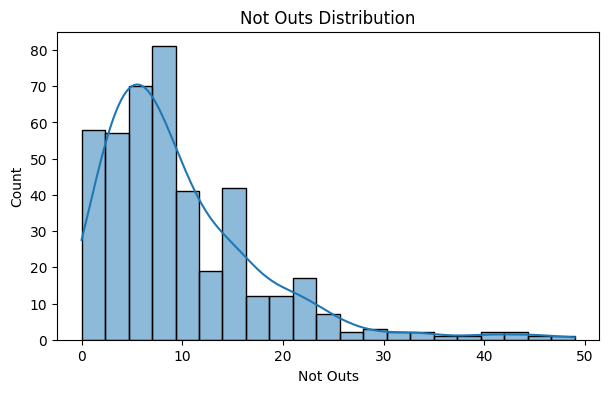

In [11]:
plt.figure(figsize=(7,4))
sns.histplot(df['Not Outs'], kde=True)
plt.title("Not Outs Distribution")
plt.show()

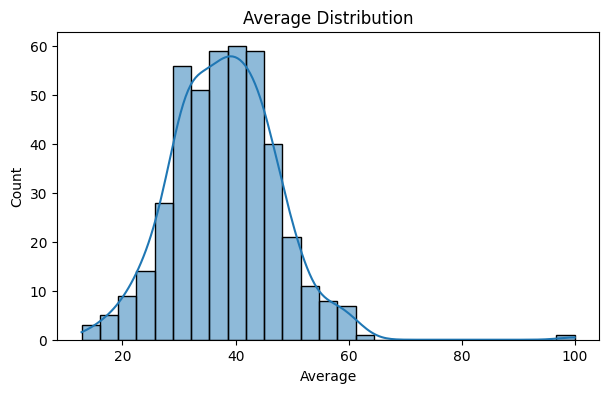

In [12]:
plt.figure(figsize=(7,4))
sns.histplot(df['Average'], kde=True)
plt.title("Average Distribution")
plt.show()

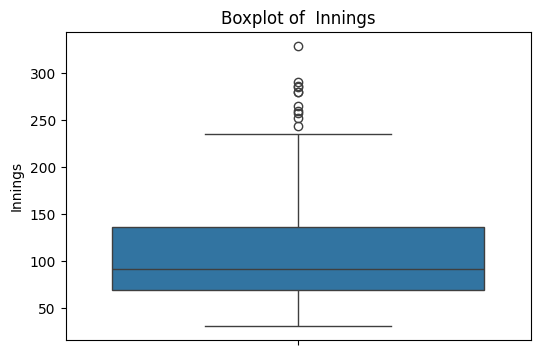

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Innings'])
plt.title("Boxplot of  Innings")
plt.show()

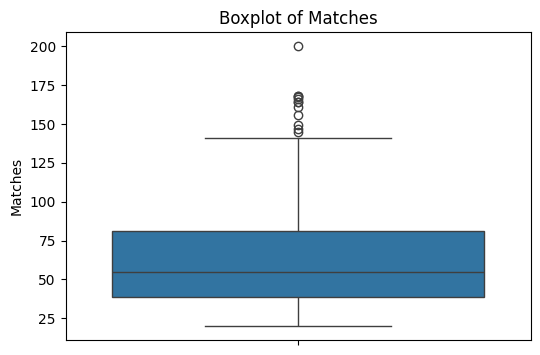

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Matches'])
plt.title("Boxplot of Matches")
plt.show()

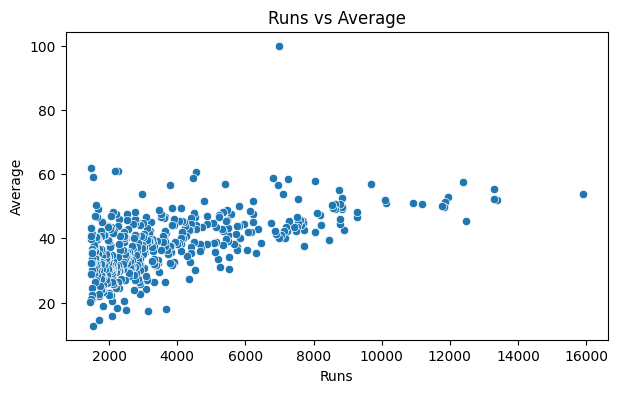

In [15]:
plt.figure(figsize=(7,4))
sns.scatterplot(x='Runs', y='Average', data=df)
plt.title("Runs vs Average")
plt.show()


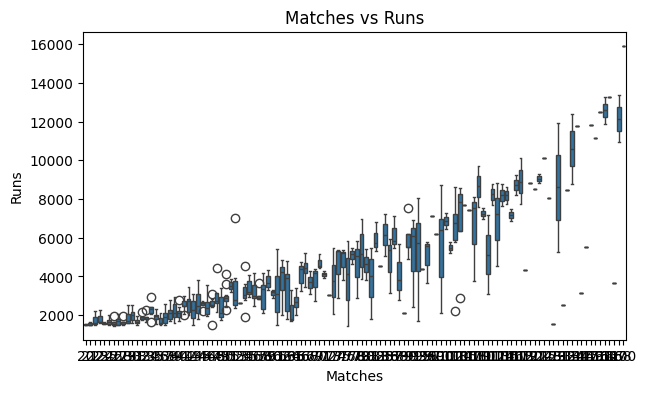

In [16]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Matches', y='Runs', data=df)
plt.title("Matches vs Runs")
plt.show()

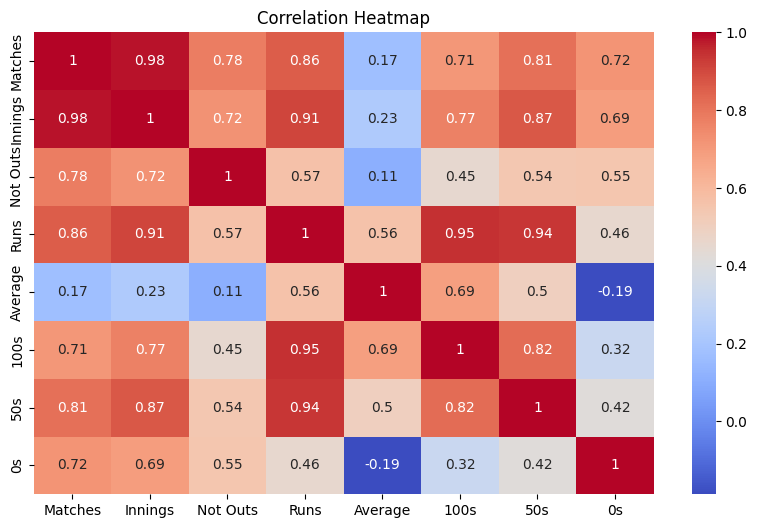

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

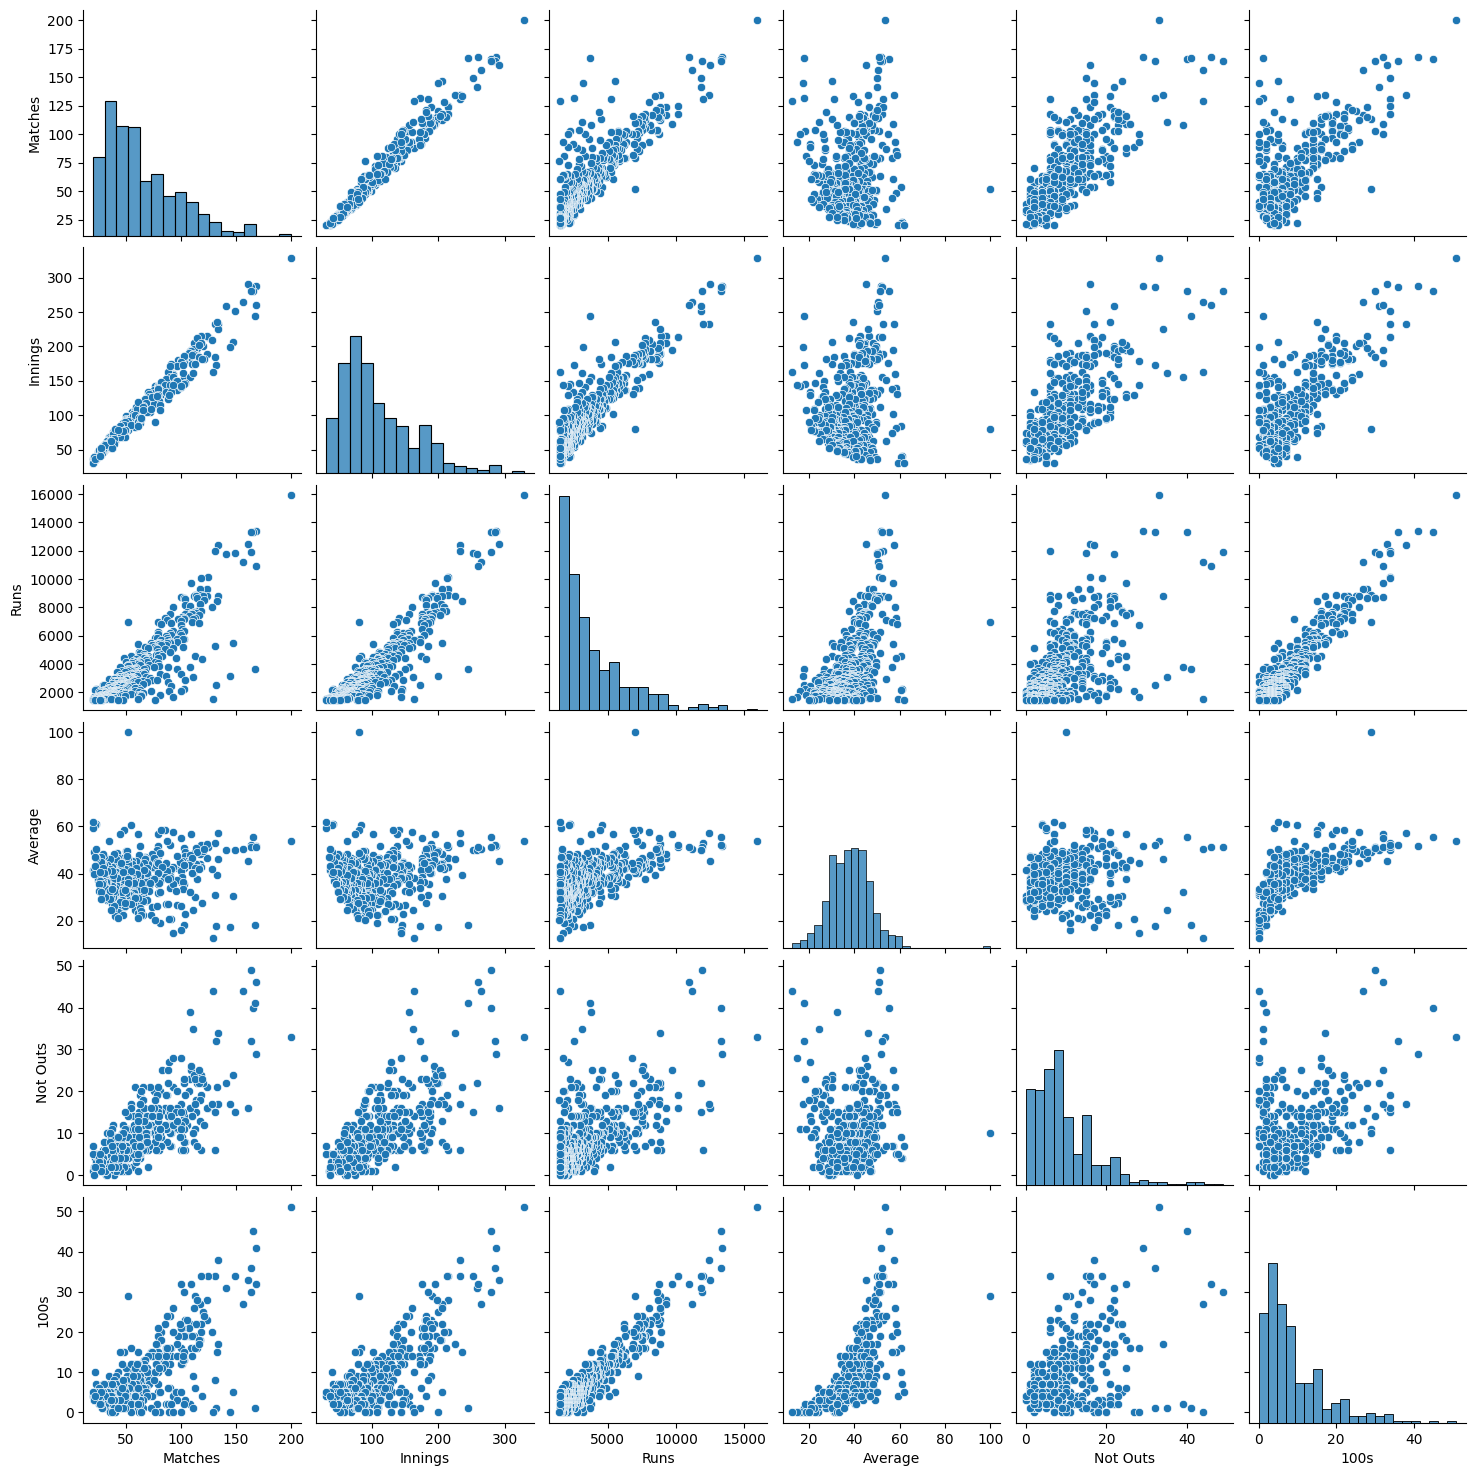

In [20]:
sns.pairplot(df[['Matches','Innings','Runs','Average','Not Outs','100s']])
plt.show()

In [23]:
X = df.drop('Average', axis=1)
y = df['Average']
X = pd.get_dummies(X, drop_first=True)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
model = LogisticRegression(max_iter=20000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,20000
,multi_class,'deprecated'


In [29]:
y_pred = model.predict(X_test)

In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9655172413793104
